# Adnaan Buksh - 47435568

In [ ]:
import os, subprocess

# --- Configuration --- #
# Video from "https://youtu.be/S-XxKVxZ2fU?si=kwMKuedxkZzgNh6p"
input_video_path = "ONE_PIECE_Trailer.mp4"
output_folder = "extracted_frames"     # Folder to save frames
frame_rate = 0.2                                  # Extract 1 frame per second
image_naming_pattern = "frame_%04d.png"         # Naming convention
max_width, max_height = 640, 480                 # Max resolution

# --- Create output folder if it doesn't exist --- #
os.makedirs(output_folder, exist_ok=True)

# --- FFmpeg command to extract frames --- #
# -i : input file
# -t : duration limit
# -vf fps=N : extracts N frames per second
# -vf scale : scales down to fit within max_width x max_height (preserves aspect ratio, no upscale)
# -q:v 2 : sets video quality (2 high, 31 low)

ffmpeg_command = [
    "ffmpeg",
    "-i", input_video_path,
    "-t", "00:02:37",
    "-vf", f"fps={frame_rate},scale='min({max_width},iw)':'min({max_height},ih)':force_original_aspect_ratio=decrease",
    os.path.join(output_folder, image_naming_pattern)
]

try:
    # Execute FFmpeg command
    subprocess.run(
        ffmpeg_command,
        check=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )

    print(f"Frames extracted successfully to: {output_folder}")

except subprocess.CalledProcessError as e:
    print(f"Error extracting frames: {e}")
    print(f"FFmpeg stderr: {e.stderr.decode()}")

except FileNotFoundError:
    print("FFmpeg command not found. Please ensure FFmpeg is installed and in your system PATH.")


Frames extracted successfully to: extracted_frames


# Task 1
The collage is built in four sequential steps: frame selection, variation scoring, layout definition, and Gaussian alpha compositing.
1.	Frame selection. All .png and .jpg files are collected from the input folder and five are chosen at random using random.sample. Each is loaded and resized to a base thumbnail size of 270 x 360 pixels purely for the scoring step.
2.	Sorting by colour variation. Each thumbnail is scored by flattening all RGB pixel values into a single array, building a 256-bin normalised histogram, and computing its standard deviation. A higher standard deviation indicates more colour diversity across the frame. Frames are sorted from lowest to highest: the least varied frame (order[0]) goes to the centre and the more varied frames fill the top, sides, and bottom.
3.	Layout and resizing. The canvas is 1080 px wide (THUMB_W x 3). The three middle panels — left, centre, and right — are all given the same width (SHARED_W = (1080 + 2x80) / 3 = 413 px) so the middle row is evenly divided. Each panel overlaps its neighbour by 80 px horizontally and 50 px vertically, which is how the blend are created. The top and bottom panels span the full 1080 px canvas width. The left, centre, and right panels are 405 px tall (1.5x the base height).
4.	Gaussian alpha compositing. For each panel a binary mask is created: 0 at the border strip and 1 in the interior. A Gaussian blur (sigma = half the fade width) smooths the mask into a soft gradient. Trial and error was used to pick an appropriate sigma value. Each panel is then composited onto the canvas using: canvas = canvas x (1 - mask) + image x mask. Painting left before right, and sides before centre, means later panels blend over earlier ones at the seams. 

-	Edge detection score not included. Canny edge density was considered as a secondary score alongside colour variation. It was excluded because the results were not looking good, maybe due to not weight the colour variation more. 
-	Greyscale histogram not used. Computing the variation score on greyscale intensity rather than RGB was considered, but the RGB histogram performed well enough in testing.

## Challenges

### Overlap Visibility
The main challenge was when overlapping the images, only one image was visible as it completely covered the one beneath it.

This was fixed using a Gaussian alpha mask:
- A binary mask is created where the border of each image is 0 (transparent) and the interior is 1 (opaque)
- A Gaussian blur is applied to this mask to make the fade gradual rather than a hard cut
- In the overlap region both images are partially visible, giving a smooth blended seam rather than one image simply sitting on top of another

### Layout and Dimension Issues
Getting the panel dimensions and anchor positions to align correctly was difficult. Issues included the canvas being too small for all five panels, the top/bottom panels not spanning the full canvas width, and the centre image being too small relative to the side panels. These were resolved by deriving all dimensions from a single canvas width constant so every panel's size and position is consistent.

### Lighting, Day/Night, and Weather Variation
Didn't really watch out for, but frames from the same video can vary significantly in brightness and colour temperature depending on the scene. This could cause blends where one image dominates.

A possible solution would be to use dynamic alpha and sigma values for the Gaussian mask.—Example, increasing sigma at seams where the brightness difference between two adjacent panels is large, producing a wider and softer blend to disguise the contrast difference.

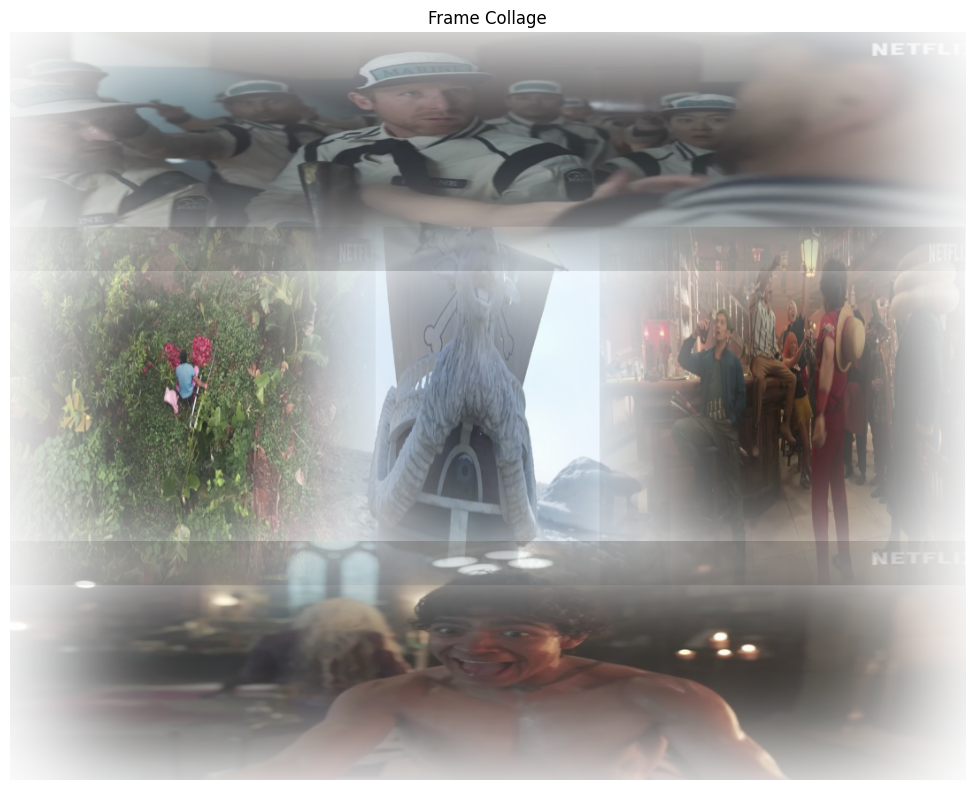

In [ ]:
from CollageCreator import CollageCreate
collage = CollageCreate("extracted_frames")

I acknowledge the use of Claude (Anthropic, 2025) to assist with the implementation of the collage layout in Task 1. Specifically, Claude was used to help work out the pixel arithmetic for positioning the five panels on the canvas — calculating anchor coordinates, overlap offsets, and canvas dimensions so that the top/bottom, side, and centre panels aligned correctly without exceeding the canvas bounds. All other aspects of the task, including the variation scoring, alpha masking approach, and Gaussian blending, were developed independently. The AI was used as a debugging and calculation aid, not to replace my own understanding of the compositing process.
Anthropic. (2025). Claude (claude-sonnet-4-6) [Large language model]. https://claude.ai

https://claude.ai/share/e8306f79-c96c-47ba-8642-dc40248d6582

# Task 2 (Hardest)

### Method Description

The approach uses chamfer matching to locate road signs in an image. A shape template (circle, square, rectangle, octagon, triangle, or diamond) is slid over a distance transform of the image's edge map. At each position the score is the mean distance-transform value under the template's edge pixels — a low score means the template edges land close to real image edges, indicating a match.

**Plan**

1. Convert to greyscale — We only need brightness info to find edges, not color

2. Find edges — Use Canny edge detection with threshold settings that adjust to how strong the edges are in the image. Use small blur (sigma 0.5) to keep fine details like sign borders

3. Distance map — Create a map where each pixel shows how far it is from the nearest edge. Pixels on edges = low value, pixels far from edges = high value

4. Create shape templates — Draw 6 different shapes (circle, square, rectangle, octagon, triangle, diamond) as edge outlines at a specific size

5. Match templates — Slide each template over the distance map at different scales. For each position, calculate the average distance value under the template's edge pixels. Lower score = better match

6. Find best matches — Record the position and scale where each shape scores lowest. Test sizes from large to small (image size down to 70 pixels)

Show results — Draw the top 3 matching shapes as boxes on the original image with shape name and score labeled

---

### Testing on All Signs

The method was tested on all provided sign images. The Canny sigma and threshold parameters needed adjustment per image depending on background complexity and sign contrast. The scale range also needed consideration — images where the sign is small relative to the scene require the range to extend further down to smaller sizes.

---

### Challenges

**Getting the Canny edges right**
The biggest challenge was tuning the Canny parameters to pick up sign edges without drowning in background noise. Early attempts with quantile thresholds produced almost no edges on busy images with cluttered backgrounds. Switching to absolute thresholds with a higher sigma gave better results, and applying a Gaussian pre-blur before Canny helped suppress tree texture and background detail before edge detection ran.

**Too many edges vs too few**
Finding the right balance was trial and error — too low a threshold and the entire image filled with edges including every tree branch and leaf, making it impossible to distinguish the sign border. Too high and almost nothing was detected. The final parameters were settled on after testing across multiple images.

**Template matching on cluttered backgrounds**
The distance transform scores were similar across many positions in busy images because background edges from trees, wires, and road markings are everywhere. This made it hard for the correct match to clearly stand out from false positives.

**Scale range**
Initially the scale range started too small — the templates were nowhere near large enough to match signs that dominated most of the image. Starting from a large scale and stepping down fixed this and the correct size was found much earlier in the search.

**False matches on image borders**
Templates near the image border were getting artificially low scores because parts of the template hung off the edge and contributed no distance transform penalty. Filling out-of-bounds regions with the maximum distance transform value when computing the correlation penalised border matches and reduced these false positives.

**Speed**
The original sliding window approach computed the score at every image position one at a time, which was too slow to be practical across a full scale range. Replacing it with correlation-based matching computed all positions simultaneously, making it fast enough to run on real images.

**General sign detection difficulty**
Designing a detector that generalises across all sign types is inherently hard — signs vary in shape, colour, size, lighting, and the amount of background clutter surrounding them. A parameter set that works well on one image often fails on another, which is why a truly general solution would require learned features rather than hand-tuned geometric templates.

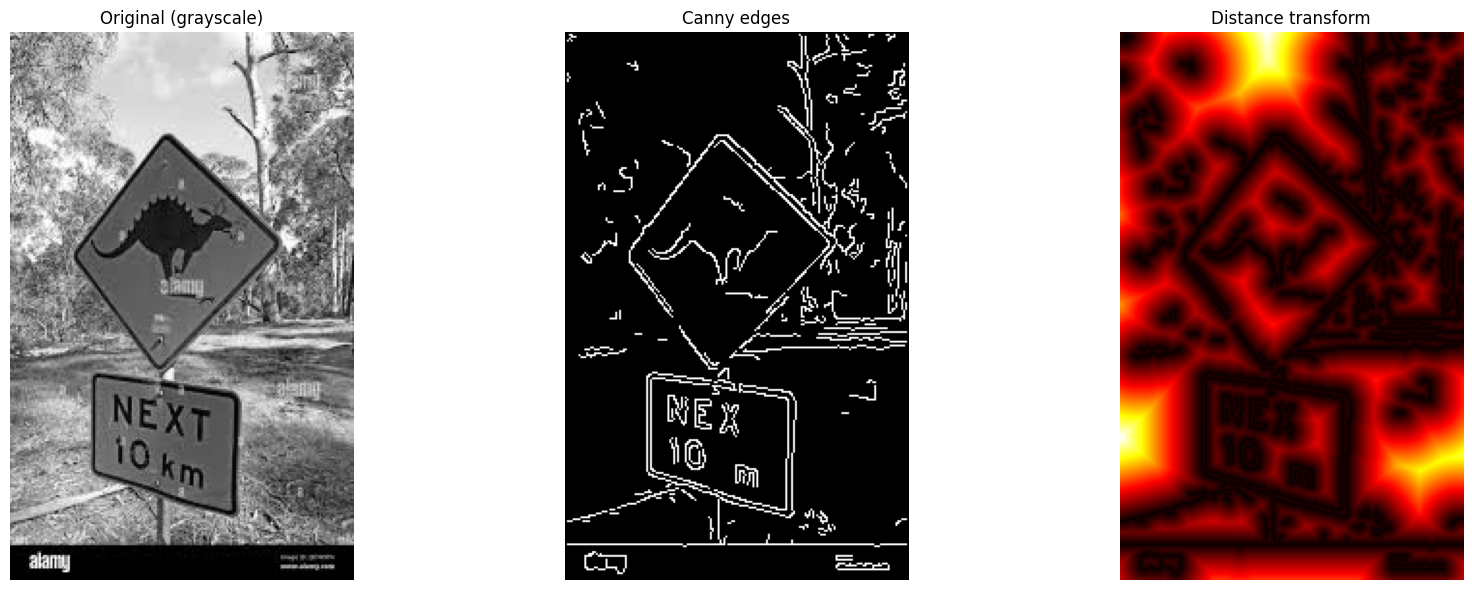

circle    : score=   1.67 at ( 216,  81) size= 79
square    : score=   1.15 at ( 213,  85) size= 89
rectangle : score=   1.32 at ( 210,  79) size= 89
octagon   : score=   1.46 at ( 204,  79) size= 84
triangle  : score=   1.70 at ( 198,  67) size= 74
diamond   : score=   1.21 at (  91,  83) size= 74


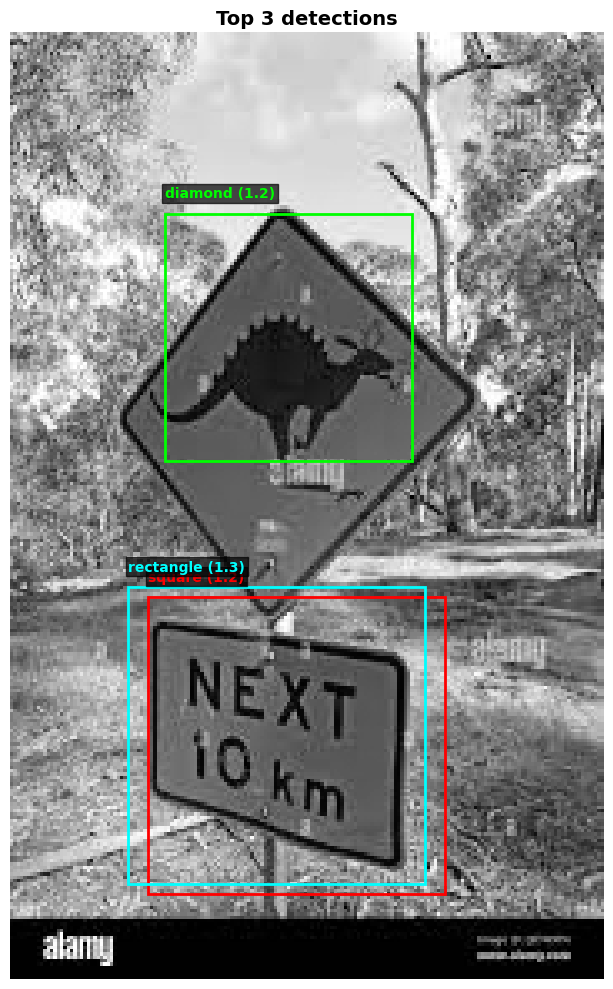

Saved → sign_detections.png


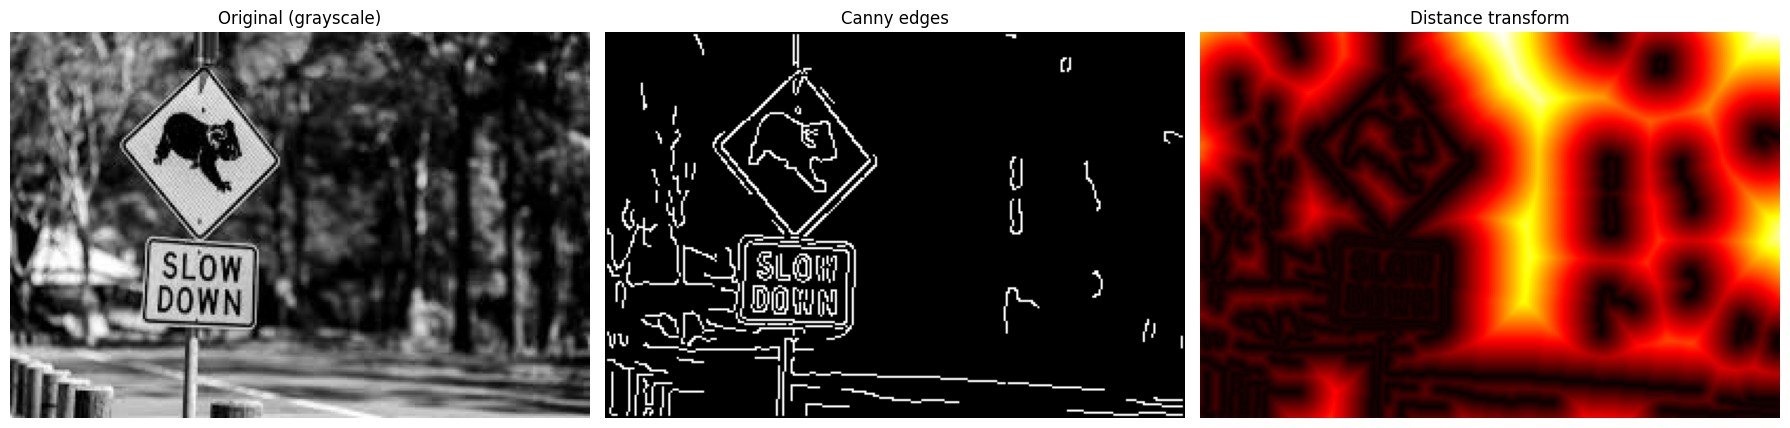

circle    : score=   1.37 at (  91,  67) size= 76
square    : score=   0.96 at ( 125,  89) size= 76
rectangle : score=   0.66 at ( 116,  90) size= 71
octagon   : score=   1.21 at (  89,  66) size= 76
triangle  : score=   0.83 at ( 116,  86) size= 71
diamond   : score=   0.66 at (  57,  89) size= 81


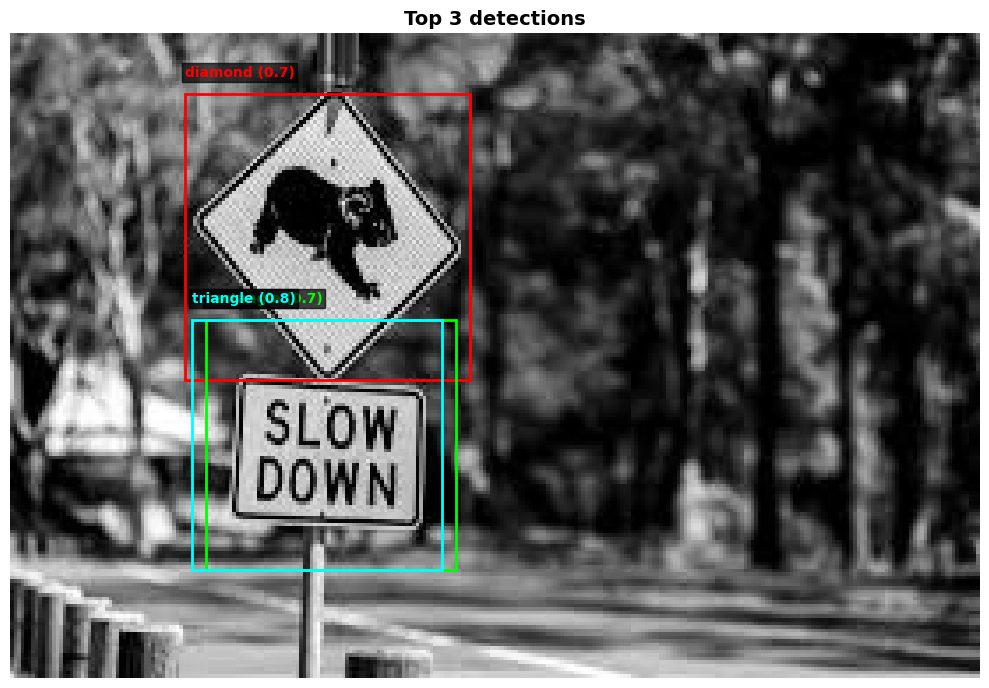

Saved → sign_detections.png


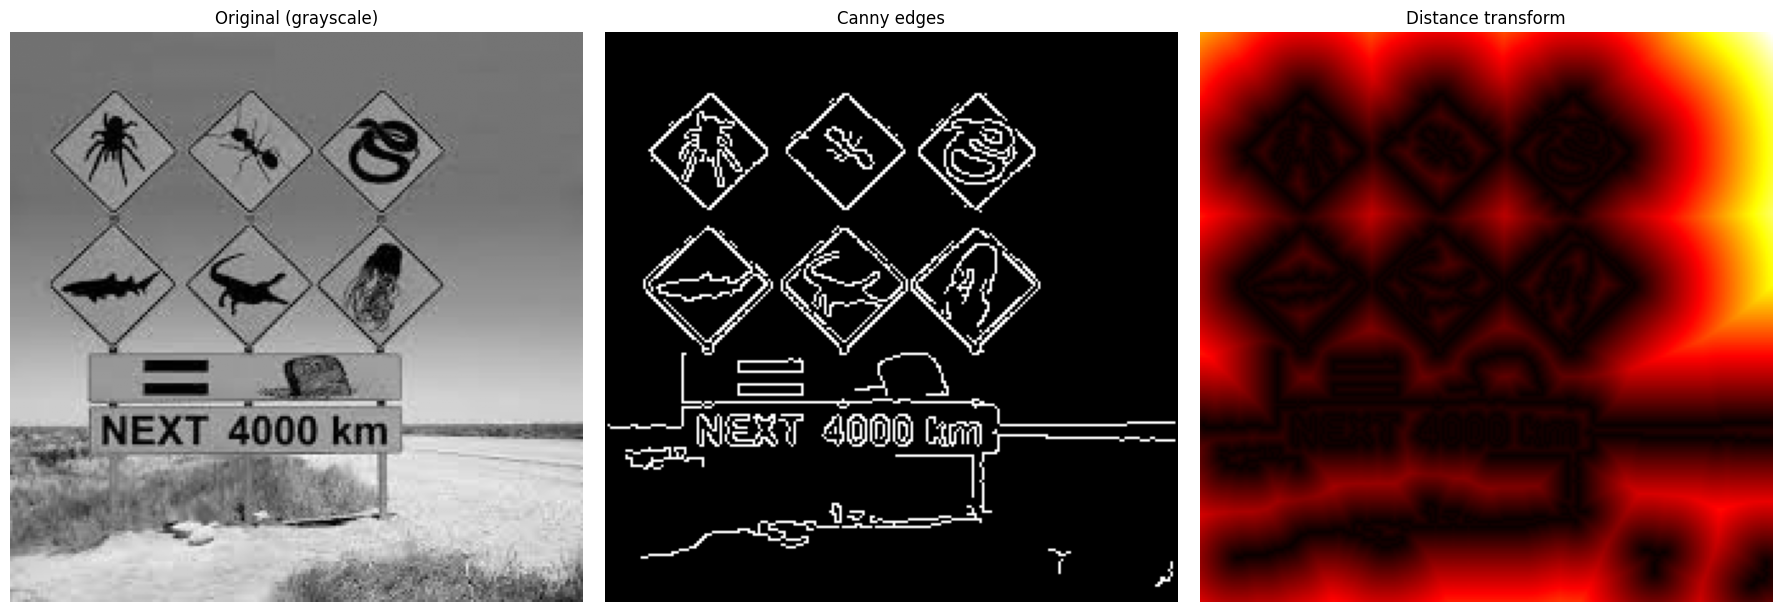

circle    : score=   1.59 at ( 128,  64) size= 72
square    : score=   1.06 at ( 121,  55) size= 72
rectangle : score=   0.78 at ( 121,  68) size= 97
octagon   : score=   1.43 at ( 128,  64) size= 77
triangle  : score=   1.35 at ( 119,  59) size= 92
diamond   : score=   1.23 at (  73,  93) size=107


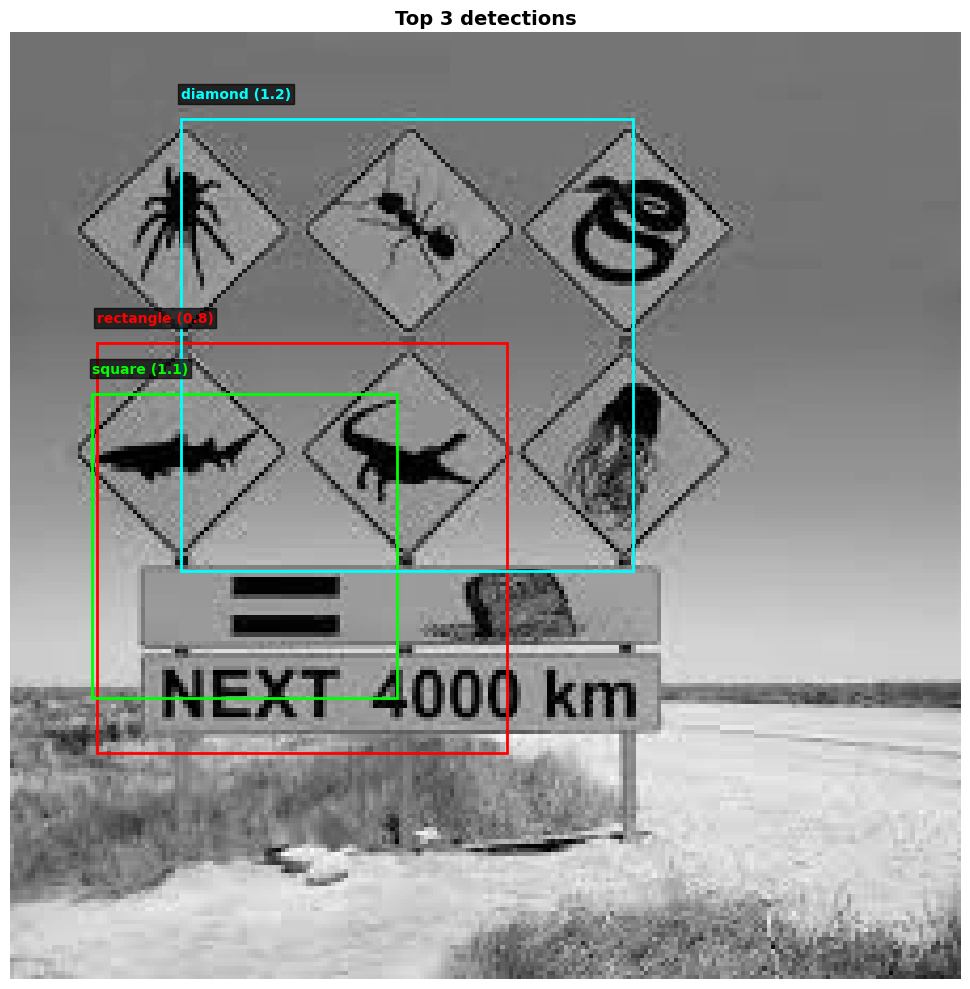

Saved → sign_detections.png


In [ ]:
from SignRecognition import SignRecognition

'''Comment on the many challenges to road sign detection including lighting,
different shaped signs, different coloured signs, perspective distortion, angle of
rotation, and so on and suggest possible solutions. '''

sign_recognition = SignRecognition("StreetSigns/Sign2.jpg")
sign_recognition = SignRecognition("StreetSigns/Sign3.jpg")
sign_recognition = SignRecognition("StreetSigns/Sign4.jpg")
#sign_recognition = SignRecognition("StreetSigns/Sign8.jpg")
#sign_recognition = SignRecognition("StreetSigns/Sign5.jpg")


I acknowledge the use of Claude (Anthropic, 2025) to assist with the implementation of the road sign detector in Task 3. Specifically, Claude was used to help design and iterate on the chamfer matching pipeline — including the distance transform scoring approach, FFT-based convolution for speed, template generation for each sign shape, and parameter tuning for the Canny edge detector across different images. Claude also helped debug issues including false matches at image borders, the scale range being too small to detect large signs, and the edge map being either too sparse or too dense depending on threshold values. The final parameter choices and the decision to use quantile-based Canny thresholds were based on my own testing and visual inspection of results across the provided sign images.
Anthropic. (2025). Claude (claude-sonnet-4-6) [Large language model]. https://claude.ai

https://claude.ai/share/e8306f79-c96c-47ba-8642-dc40248d6582

## Task 3

### K-means Clustering

K-means groups all pixels in the image into `k` colour clusters. Each pixel is then replaced by its cluster centre colour, reducing the image to a flat poster-like palette.

- KMeans from sklearn was used
- `k=18` was used after trial and error.
- higher k means more colours and a more realistic result, lower k gives a stronger cartoon effect

---

### Bilateral Filtering

The bilateral filter smooths colour regions while preserving edges. Unlike a regular Gaussian blur which blurs everything, bilateral only blends pixels that are both spatially close **and** similar in colour.

- denoise_bilateral from skimage was used
- after trial and error the following vauels were chossen 
- `sigma_color=0.05` — only pixels with very similar colours are blended, keeping edges sharp
- `sigma_spatial=10` — pixels up to 10px apart can influence each other
- Applied 3 times (`n_iter=3`) — each pass smooths more, building up a painterly effect
- The result has smooth flat regions and visible edges but no explicit edge overlay

---

### Improved Method

The improved method combines skin segmentation (from tuts), K-means quantisation and blurred background.

**Plan:**

1. **Skin segmentation** using HSV thresholds — detects skin-tone pixels (warm hue, moderate saturation and brightness). A Gaussian blur on the mask creates a soft transition at the skin boundary
2. **K-means foreground** (`k=24`) — quantises the whole image into 24 colour clusters, preserving more colour detail than the basic K-means
3. **Blurred background** — Gaussian blur (`sigma=6`) applied to the original image as the background layer
4. **Soft blend** — foreground (quantised) and background (blurred) are blended using the soft skin mask: `result = foreground × mask + background × (1 − mask)`
5. **Saturation boost** (`×1.4`) in HSV space — recovers vividness lost during blending (AI Help as the image lost colour)

**Output differences vs K-means and bilateral:**
- Background is visibly softer/blurred, drawing focus to the subject
- Skin tones are smooth but retain colour, unlike the flat blocks of basic K-means
- More vibrant than bilateral which can look washed out

---

### Challenges and Possible Solutions

**Skin segmentation accuracy**
The HSV threshold is a rough approximation and can miss darker skin tones or falsely detect warm-coloured clothing and backgrounds.
- Use a dual RGB + HSV condition (Peer et al. 2003, Sobotka et al. 1998) for more robust detection

**Colour loss after blending**
Blending the quantised foreground with a blurred background reduces overall saturation, making the result look washed out.
- Increase `k` to preserve more of the original colour palette in the foreground
- Apply a saturation boost in HSV space after blending to recover vividness

**Getting a good output**
Getting the improved method to look like a cartoon rather than a sketch or anime required significant trial and error with the parameters and pipeline steps.

- A Canny edge overlay was tested but produced a sketch-like effect with heavy black outlines that made the result look more like anime than a cartoon — this was removed from the final implementation
- Parameters such as `k`, `sigma_color`, `sigma_spatial`, `sigma` for the background blur, and the saturation multiplier were all tuned manually by running the method on the test image and comparing outputs

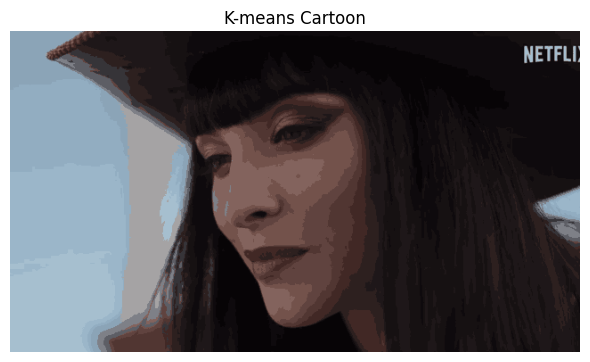

Saved -> task2_kmeans.png


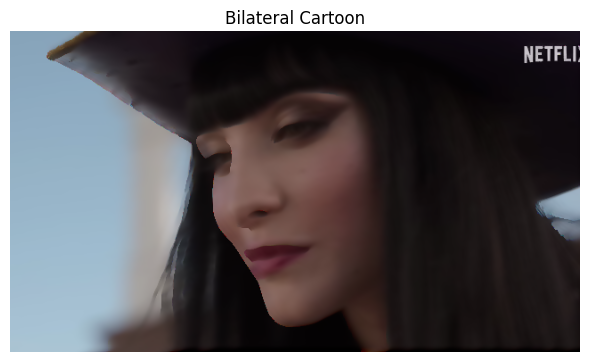

Saved -> task2_bilateral.png


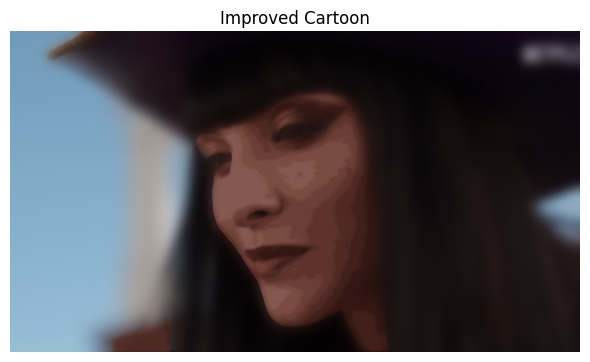

Saved -> task2_improved.png


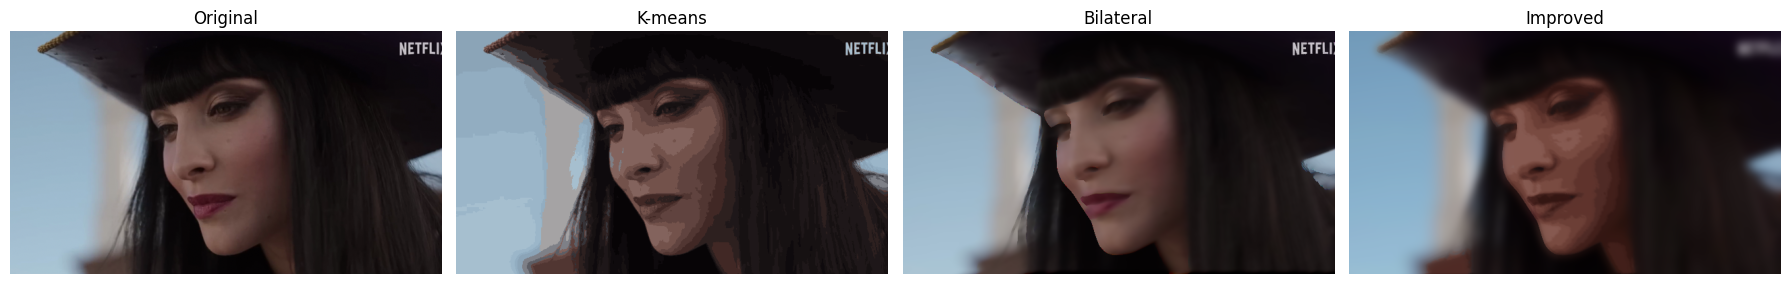

In [ ]:
from CartoonNizer import CartoonNizer

'''detailed report mentioning K-means clustering, Bilateral filtering-based, and
your own improvements with output differences. Comment on the many
challenges and suggest possible solutions. '''

cartoon_nizer = CartoonNizer("extracted_frames/frame_0015.png")

I acknowledge the use of Claude (Anthropic, 2025) to assist with the implementation of the CartoonNizer in Task 2. Specifically, Claude was used to help build and iterate on the improved method — suggesting the combination of skin segmentation, K-means foreground quantisation, blurred background blending, and saturation boosting, as well as helping debug parameter choices and pipeline ordering. Claude also helped explain the difference between using Canny edges versus segmentation-based boundaries and why the Canny overlay was producing a sketch/anime look rather than a cartoon look. All three method implementations were reviewed and understood before being used, and the final parameter values were chosen based on my own testing and visual judgement on the output images.
Anthropic. (2025). Claude (claude-sonnet-4-6) [Large language model]. https://claude.ai

https://claude.ai/share/e8306f79-c96c-47ba-8642-dc40248d6582